# Athletic spending and graduation rates at NCAA public institutions
 
Question: does the share of expenses going to athletics predict 6-year graduation rates once we account for who the school enrolls?
 
Data is IPEDS 2022-23 (finance, admissions, financial aid, graduation) joined to NCAA classification. 445 public institutions. Hospital and independent operations expenses are removed from total expenses so med-center schools don't look like they spend 3x per student.
 
Every regression here is weighted by cohort size. A grad rate from 5000 students is a lot more precise than one from 80. Standard errors are HC3 robust.

In [94]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import RepeatedKFold, cross_validate
from sklearn.feature_selection import RFECV, RFE
from sklearn.metrics import root_mean_squared_error, r2_score
from sklearn.inspection import PartialDependenceDisplay
import statsmodels.api as sm
import statsmodels.formula.api as smf

Load Data

In [95]:
features = pd.read_csv("../Data/Clean/features.csv")

featuresFilled = features.fillna(features.median(numeric_only=True))

Tests

Build up the spendRate coefficient one control at a time: pooled, + division, + size, + student composition. The point is to watch how the estimate moves as controls get added.
 
The R side did this unweighted as an exploratory pass. This is the primary version.

In [96]:
# Pooled
m_pooled = smf.wls("gradRate ~ spendRate", data=featuresFilled,
                   weights=featuresFilled["cohortSize"]).fit(cov_type="HC3")
print(m_pooled.summary())
print(m_pooled.params["spendRate"])

                            WLS Regression Results                            
Dep. Variable:               gradRate   R-squared:                       0.002
Model:                            WLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                    0.7988
Date:                Thu, 03 Sep 2026   Prob (F-statistic):              0.372
Time:                        00:38:57   Log-Likelihood:                 123.20
No. Observations:                 445   AIC:                            -242.4
Df Residuals:                     443   BIC:                            -234.2
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.6586      0.018     36.509      0.0

In [97]:
m_additive = smf.wls("gradRate ~ spendRate + C(division)", data=featuresFilled,
                     weights=featuresFilled["cohortSize"]).fit(cov_type="HC3")
print(m_additive.summary())

                            WLS Regression Results                            
Dep. Variable:               gradRate   R-squared:                       0.333
Model:                            WLS   Adj. R-squared:                  0.325
Method:                 Least Squares   F-statistic:                     28.78
Date:                Thu, 03 Sep 2026   Prob (F-statistic):           2.91e-25
Time:                        00:38:57   Log-Likelihood:                 212.68
No. Observations:                 445   AIC:                            -413.4
Df Residuals:                     439   BIC:                            -388.8
Df Model:                           5                                         
Covariance Type:                  HC3                                         
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept   

In [98]:
m_interaction = smf.wls("gradRate ~ spendRate * C(division)", data=featuresFilled, weights=featuresFilled["cohortSize"]).fit(cov_type="HC3")
print(m_interaction.summary())

                            WLS Regression Results                            
Dep. Variable:               gradRate   R-squared:                       0.344
Model:                            WLS   Adj. R-squared:                  0.331
Method:                 Least Squares   F-statistic:                     25.71
Date:                Thu, 03 Sep 2026   Prob (F-statistic):           1.76e-35
Time:                        00:38:57   Log-Likelihood:                 216.50
No. Observations:                 445   AIC:                            -413.0
Df Residuals:                     435   BIC:                            -372.0
Df Model:                           9                                         
Covariance Type:                  HC3                                         
                                               coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------

In [99]:
print(sm.stats.anova_lm(m_additive, m_interaction))

   df_resid           ssr  df_diff     ss_diff         F    Pr(>F)
0     439.0  15065.644848      0.0         NaN       NaN       NaN
1     435.0  14809.664316      4.0  255.980532  1.879711  0.112964


No evidence the slope differs by division (F = 1.88, p = 0.11). The additive model is enough.


Size control. Big schools spend a smaller share on athletics and graduate more, so leaving size out could bias the spending coefficient.

In [100]:
m_size = smf.wls("gradRate ~ spendRate + np.log(totalExp) + C(division)", data=featuresFilled,
                 weights=featuresFilled["cohortSize"]).fit(cov_type="HC3")
print(m_size.params['spendRate'], m_size.pvalues['spendRate'])

0.7255524818480674 9.766676971232332e-05


Levels check: log athletic spending and log total spending as separate terms, to make sure the size-adjusted result isn't just an artifact of dividing by totalExp.

In [101]:
m_alt = smf.wls("gradRate ~ np.log(sportsExpenses) + np.log(totalExp) + C(division)",
                data=featuresFilled, weights=featuresFilled["cohortSize"]).fit(cov_type="HC3")
print(m_alt.summary())

                            WLS Regression Results                            
Dep. Variable:               gradRate   R-squared:                       0.665
Model:                            WLS   Adj. R-squared:                  0.660
Method:                 Least Squares   F-statistic:                     118.8
Date:                Thu, 03 Sep 2026   Prob (F-statistic):           1.26e-88
Time:                        00:38:57   Log-Likelihood:                 365.77
No. Observations:                 445   AIC:                            -717.5
Df Residuals:                     438   BIC:                            -688.9
Df Model:                           6                                         
Covariance Type:                  HC3                                         
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept   

Full composition: Pell share, test scores, log enrollment, admission rate and its missing flag. These are the student-body variables the ML section ends up picking as the main predictors.

In [115]:
m_final = smf.wls("gradRate ~ spendRate + upPell + testScore + np.log(ugTotal) + admRate + admRateMissing + C(division)",
                  data=featuresFilled, weights=featuresFilled["cohortSize"]).fit(cov_type="HC3")
print(m_final.summary())

                            WLS Regression Results                            
Dep. Variable:               gradRate   R-squared:                       0.820
Model:                            WLS   Adj. R-squared:                  0.816
Method:                 Least Squares   F-statistic:                     228.2
Date:                Thu, 03 Sep 2026   Prob (F-statistic):          7.15e-166
Time:                        00:40:01   Log-Likelihood:                 504.72
No. Observations:                 445   AIC:                            -987.4
Df Residuals:                     434   BIC:                            -942.4
Df Model:                          10                                         
Covariance Type:                  HC3                                         
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept   

spendRate coefficient path:
 
pooled -0.20 (p = 0.37, nothing)
+ division -1.19 (p < 0.001)
+ size +0.73 (p < 0.001)
+ composition -0.35 (p = 0.002)
Two sign flips across specifications is a clear sign of confounding, not of an effect.

In [119]:
wlsFull = pd.DataFrame({"coef": m_final.params, "se": m_final.bse, "p": m_final.pvalues, "ci_lo": m_final.conf_int()[0], "ci_hi": m_final.conf_int()[1]}).round(4)
wlsFull

,coef,se,p,ci_lo,ci_hi
Intercept,0.0170,0.1134,0.8809,-0.2053,0.2393
C(division)[T.D-I FCS],-0.0028,0.0166,0.8666,-0.0353,0.0297
C(division)[T.D-I no football],0.0051,0.0163,0.7522,-0.0267,0.0370
C(division)[T.D-II],-0.0088,0.0169,0.6033,-0.0420,0.0244
C(division)[T.D-III],0.0196,0.0187,0.2948,-0.0170,0.0562
spendRate,-0.3455,0.1089,0.0015,-0.5590,-0.1321
upPell,-0.4119,0.0359,0.0000,-0.4822,-0.3416
testScore,0.0003,0.0001,0.0000,0.0002,0.0004
np.log(ugTotal),0.0571,0.0087,0.0000,0.0401,0.0741
admRate,-0.2380,0.0269,0.0000,-0.2907,-0.1852


In [120]:
cutoff = featuresFilled["cohortSize"].quantile(0.95)
trimmed = featuresFilled[featuresFilled["cohortSize"] < cutoff]

m_trim = smf.wls("gradRate ~ spendRate + upPell + testScore + np.log(ugTotal) + admRate + admRateMissing + C(division)",
                 data=trimmed, weights=trimmed["cohortSize"]).fit(cov_type="HC3")

print(f"n = {len(trimmed)} (dropped {len(featuresFilled) - len(trimmed)} largest cohorts)")
print(f"spendRate: {m_trim.params['spendRate']:.3f}, p = {m_trim.pvalues['spendRate']:.3f}, "
      f"CI [{m_trim.conf_int().loc['spendRate', 0]:.3f}, {m_trim.conf_int().loc['spendRate', 1]:.3f}]")

n = 422 (dropped 23 largest cohorts)
spendRate: -0.231, p = 0.066, CI [-0.478, 0.015]


The weighted -0.35 (p = 0.002) depends on the biggest cohorts. Dropping the top 5% gives -0.23, p = 0.07, basically the same as the unweighted estimate. 
So: small, negative, and not robustly different from zero.

Machine Learning Models

Four models on the same preprocessing, compared by 5x5 repeated CV RMSE on an 80% training split (stratified by division). Weights are cohort size like above. The 20% test split stays untouched until the final model.

In [102]:
num = ["spendRate", "expPerStudent", "ugTotal", "admRate", "testScore",
       "upPell", "instrShare", "adminShare"]
ind = ["testScoreMissing", "admRateMissing"]
cat = ["division"]

X = features[num + ind + cat].assign(
    expPerStudent=lambda d: np.log(d["expPerStudent"]),
    ugTotal=lambda d: np.log(d["ugTotal"]),
)
y = features["gradRate"]
w = features["cohortSize"]

preprocess = ColumnTransformer([
    ("num", Pipeline([("impute", SimpleImputer(strategy="median")),
                      ("scale",  StandardScaler())]), num),
    ("ind", "passthrough", ind),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat),
])

models = {
    "linear": LinearRegression(),
    "ridge": Ridge(alpha=1.0),
    "randomForest": RandomForestRegressor(n_estimators=500, random_state=42),
    "gbm": GradientBoostingRegressor(random_state=42)
}

pipes = {name: Pipeline([("prep", preprocess), ("model", m)])
         for name, m in models.items()}

cv = RepeatedKFold(n_splits= 5, n_repeats = 5, random_state= 42)

X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(X, y, w, test_size = .20, random_state = 42, stratify = features["division"])

results = {}
for name, pipe in pipes.items():
    res = cross_validate(pipe, X_train, y_train, cv=cv,
                         scoring=["neg_root_mean_squared_error", "r2"],
                         params={"model__sample_weight": w_train})
    results[name] = {
        "rmse_mean": -res["test_neg_root_mean_squared_error"].mean(),
        "rmse_sd":    res["test_neg_root_mean_squared_error"].std(),
        "r2_mean":    res["test_r2"].mean(),
        "r2_sd":      res["test_r2"].std(),
    }

cv_table = pd.DataFrame(results).T.round(3)
print(cv_table)

              rmse_mean  rmse_sd  r2_mean  r2_sd
linear            0.080    0.009    0.700  0.076
ridge             0.080    0.009    0.700  0.076
randomForest      0.083    0.008    0.682  0.074
gbm               0.079    0.008    0.708  0.058


GBM wins by a hair (RMSE 0.079, R2 0.71). Linear and ridge are within one SD of it, so the relationship is mostly additive and monotone. The GBM's edge is a few nonlinearities that show up later in the PDPs.

Ablation of GBM model

RFECV asks how many features we actually need. The CV curve goes flat after a point, so the argmax is unreliable. Using the one-standard-error rule instead: smallest feature count whose RMSE is within 1 SE of the best.

In [103]:
minFeatures = 1
GBModel = Pipeline([("prep", preprocess), ("featureSelec", RFECV(estimator= GradientBoostingRegressor(random_state=42), cv=cv, scoring="neg_root_mean_squared_error", 
                                                                 min_features_to_select=minFeatures)),
                    ("model", GradientBoostingRegressor(random_state=42))])
GBModel.fit(X_train, y_train, model__sample_weight=w_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('featureSelec', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['spendRate','expPerStudent','ugTotal',...,'testScoreMissing', 'admRateMissing','division']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('ind', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed th

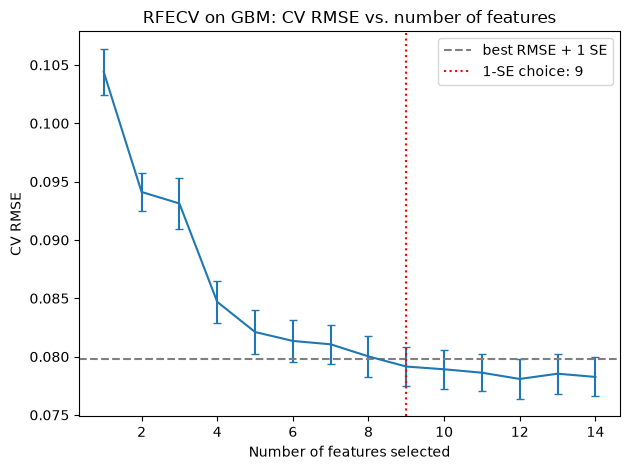

In [104]:
sel = GBModel.named_steps["featureSelec"]
n_folds = cv.get_n_splits()

cv_results = pd.DataFrame({
    "n_features": sel.cv_results_["n_features"],
    "rmse": -sel.cv_results_["mean_test_score"],
    "se": sel.cv_results_["std_test_score"] / np.sqrt(n_folds),
})

best = cv_results["rmse"].min()
threshold = best + cv_results.loc[cv_results["rmse"].idxmin(), "se"]
n_one_se = cv_results.loc[cv_results["rmse"] <= threshold, "n_features"].min()

figRfecv = plt.figure()
plt.errorbar(cv_results["n_features"], cv_results["rmse"], yerr=cv_results["se"], capsize=3)
plt.axhline(threshold, ls="--", color="gray", label="best RMSE + 1 SE")
plt.axvline(n_one_se, ls=":", color="red", label=f"1-SE choice: {n_one_se}")
plt.xlabel("Number of features selected")
plt.ylabel("CV RMSE")
plt.title("RFECV on GBM: CV RMSE vs. number of features")
plt.legend()
plt.tight_layout()
plt.show()

About 9 of the 14 encoded features are enough, the last 5 add nothing measurable. But RFE ranks features by GBM impurity importance, which undercounts binary columns. Ablation next to check it.

In [105]:
GBModel2 = Pipeline([("prep", preprocess), ("featureSelec", RFE(estimator= GradientBoostingRegressor(random_state=42), n_features_to_select=1)),
                    ("model", GradientBoostingRegressor(random_state=42))])
GBModel2.fit(X_train, y_train, model__sample_weight=w_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('featureSelec', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['spendRate','expPerStudent','ugTotal',...,'testScoreMissing', 'admRateMissing','division']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('ind', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed th

Ranking

In [106]:
names = GBModel2["prep"].get_feature_names_out()
order = pd.Series(GBModel2["featureSelec"].ranking_, index=names).sort_values(ascending=False)
print(order)
print(X_train.columns)

cat__division_D-I FCS            14
cat__division_D-I no football    13
ind__testScoreMissing            12
cat__division_D-III              11
cat__division_D-II               10
ind__admRateMissing               9
num__adminShare                   8
num__instrShare                   7
num__spendRate                    6
num__expPerStudent                5
num__admRate                      4
num__upPell                       3
num__ugTotal                      2
num__testScore                    1
dtype: int64
Index(['spendRate', 'expPerStudent', 'ugTotal', 'admRate', 'testScore',
       'upPell', 'instrShare', 'adminShare', 'testScoreMissing',
       'admRateMissing', 'division'],
      dtype='str')


Ablation

Drop-column ablation. Refit the GBM with each raw column removed and measure how much CV RMSE goes up vs the full model. The CV folds are fixed, so the differences are computed fold by fold (paired), which cancels out the "this fold was hard" noise.
 
Two extra rows drop groups together: the four spending variables, and admRate with its missing flag. This catches variables that are redundant individually but matter jointly.

In [107]:
results2 = {}

def makePipeline(dropCols):

    num2 = [c for c in num if c not in dropCols]
    ind2 = [c for c in ind if c not in dropCols]
    cat2 = [c for c in cat if c not in dropCols]

    preprocess2 = ColumnTransformer([
        ("num2", Pipeline([("impute", SimpleImputer(strategy="median")),
                           ("scale",  StandardScaler())]), num2),
        ("ind2", "passthrough", ind2),
        ("cat2", OneHotEncoder(drop="first", handle_unknown="ignore"), cat2),
        ])

    GBModel3 = Pipeline([("prep", preprocess2), ("model", GradientBoostingRegressor(random_state=42))])
    return GBModel3
def buildGBMDropCols(dropCols):
    
    GBModel3 = makePipeline(dropCols)
    X_model = X_train.drop(columns=dropCols)

    res = cross_validate(GBModel3, X_model, y_train, cv=cv,
                        scoring=["neg_root_mean_squared_error"],
                        params={"model__sample_weight": w_train})
    return(-res["test_neg_root_mean_squared_error"])

results2["Base"] = {"rmse": buildGBMDropCols([])}

for col in X_train.columns:     # Drop columns 1 by 1
    results2[col] = {"rmse": buildGBMDropCols([col])}

results2["spending"]    = {"rmse": buildGBMDropCols(["spendRate", "expPerStudent", "instrShare", "adminShare"])}
results2["admRatePair"] = {"rmse": buildGBMDropCols(["admRate", "admRateMissing"])}

In [108]:
rmseScores = {col: results2[col]["rmse"] for col in results2.keys()}
rmseScores = pd.DataFrame(rmseScores).transpose()
baseScores = rmseScores.loc["Base"]
rmseSubs = rmseScores - baseScores

deltaTable = pd.DataFrame()
deltaTable["Mean"]= rmseSubs.drop(index=["Base"]).mean(axis=1)
deltaTable["SE"] = rmseSubs.drop(index=["Base"]).std(axis=1, ddof=1) / np.sqrt(cv.get_n_splits())
deltaTable["Mean/SE"] = deltaTable["Mean"] / deltaTable["SE"]
deltaTable["pct"] = 100 * deltaTable["Mean"] / rmseScores.loc["Base"].mean()

deltaTable = deltaTable.sort_values("Mean")
print(deltaTable)

                      Mean        SE    Mean/SE        pct
instrShare        0.000134  0.000456   0.293563   0.168829
spendRate         0.000183  0.000503   0.365128   0.231195
testScoreMissing  0.000308  0.000275   1.123475   0.388702
expPerStudent     0.000446  0.001009   0.442441   0.562264
admRateMissing    0.000497  0.000432   1.148327   0.625697
admRate           0.000972  0.000789   1.232952   1.225288
adminShare        0.001040  0.000639   1.628543   1.310842
division          0.001493  0.000383   3.901490   1.881420
spending          0.001493  0.000906   1.648876   1.881447
admRatePair       0.002188  0.000898   2.436676   2.757052
ugTotal           0.004573  0.000875   5.224227   5.761838
testScore         0.005539  0.001059   5.228527   6.979609
upPell            0.009188  0.000671  13.697260  11.576971


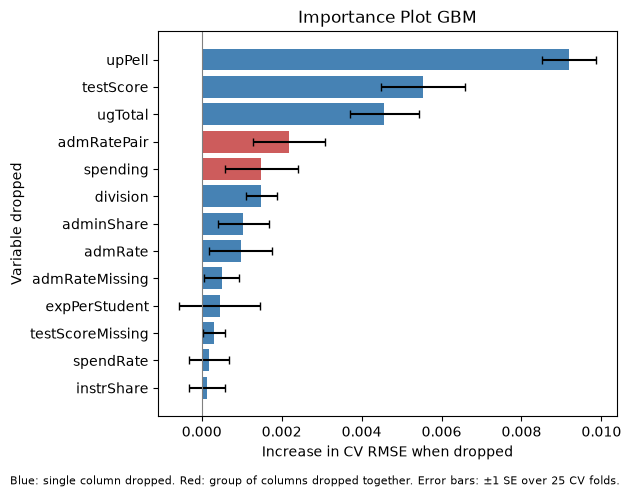

In [109]:
color = ["steelblue"  if c not in ["spending", "admRatePair"] else "indianred" for c in deltaTable.index]

figAblation = plt.figure()
plt.barh(deltaTable.index, deltaTable["Mean"], xerr=deltaTable["SE"],
         capsize=3, color = color)
plt.xlabel("Increase in CV RMSE when dropped")
plt.ylabel("Variable dropped")
plt.title("Importance Plot GBM")
plt.axvline(0, color="gray", lw=0.8)
plt.figtext(0.5, -0.02, "Blue: single column dropped. Red: group of columns dropped together. Error bars: ±1 SE over 25 CV folds.",
            ha="center", fontsize=8)
plt.tight_layout()
plt.show()

RFE was wrong about division. It's worth about 2% of baseline RMSE (Mean/SE ~ 3.9). Impurity importance in GBM undercounts binary features, which is exactly what the one-hot dummies are.
 
Spending is unimportant no matter how it's sliced: individually or as a group (1.6 SE). The admission rate pair is marginally relevant together (2.4 SE) but not separately, so they stay in as a pair.

Final model: drop the spending block and testScoreMissing, refit on train, score once on the held-out 20%.

In [110]:
dropList = ["spendRate", "expPerStudent", "instrShare", "adminShare", "testScoreMissing"]

finalModel = makePipeline(dropList)
finalModel = finalModel.fit(X_train.drop(columns=dropList), y_train, model__sample_weight = w_train)

y_pred = finalModel.predict(X_test.drop(columns=dropList))

r2 = r2_score(y_test, y_pred)
print(r2)

rmse = root_mean_squared_error(y_test, y_pred)
print(rmse)

0.8231062751548848
0.06790230917055966


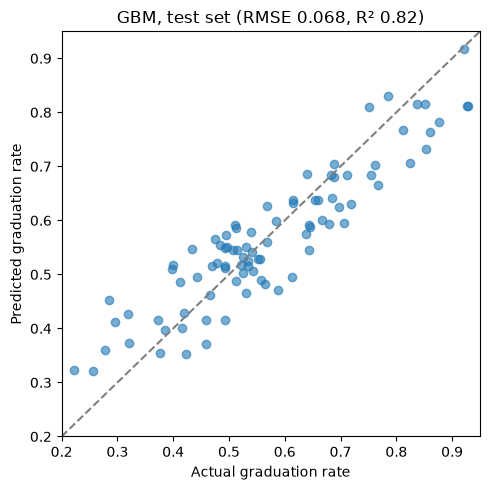

In [111]:
figPred = plt.figure(figsize=(5, 5))
plt.scatter(y_test, y_pred, alpha=0.6)
lims = [0.2, 0.95]
plt.plot(lims, lims, "--", color="gray")
plt.xlim(lims); plt.ylim(lims)
plt.xlabel("Actual graduation rate")
plt.ylabel("Predicted graduation rate")
plt.title(f"GBM, test set (RMSE {rmse:.3f}, R² {r2:.2f})")
plt.tight_layout()
plt.show()

Test RMSE 0.068, R2 0.82. A bit better than CV, which is within what one 89-school split can do. The model compresses the extremes by 5-10 points (predicts too high for the worst schools, too low for the best), which is normal for tree ensembles on a bounded target.

Partial Dependence Plots

Partial dependence: average predicted grad rate as one feature is moved across its range and everything else is held at real values. Gives direction and shape. Tick marks at the bottom are data deciles, the curve isn't trustworthy where they're sparse. ugTotal is log scale.

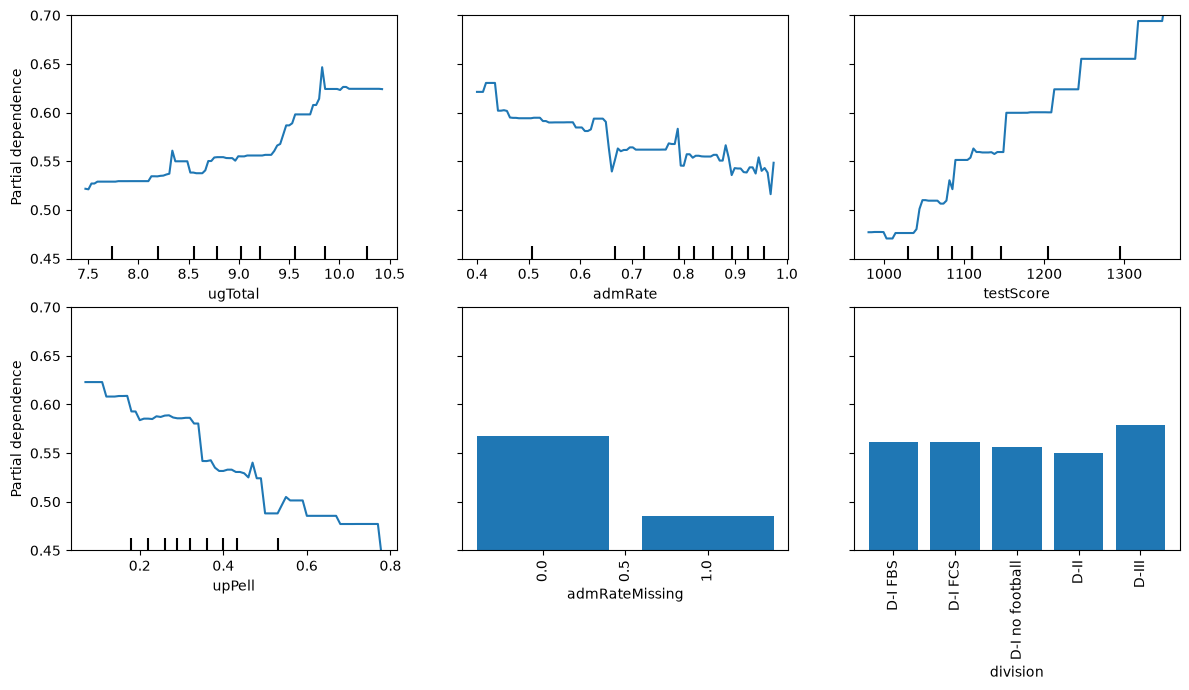

In [117]:
X_pd = X_train.drop(columns=dropList)
X_pd = X_pd.fillna(X_pd.median(numeric_only=True))

figPdpFinal, axes = plt.subplots(figsize=(12, 7))
PartialDependenceDisplay.from_estimator(finalModel, X_pd, features=list(X_pd.columns),
                                        categorical_features=["division", "admRateMissing"],
                                        kind="average", n_cols=3, ax=axes)
for a in figPdpFinal.axes: a.set_ylim(0.45, 0.70)
plt.tight_layout(); plt.show()


Bigger schools and higher test scores are associated with higher graduation rates.
 
Higher admission rates, a missing admission rate, and a higher Pell share are associated with lower graduation rates.
 
D-III sits a couple points above everyone else. The three D-I classifications are basically indistinguishable, so football status does nothing once composition is controlled.

Same thing for the four spending variables, on the full-feature model since they're not in the final one. Y-axis matched to the previous figure so the effect sizes are comparable.

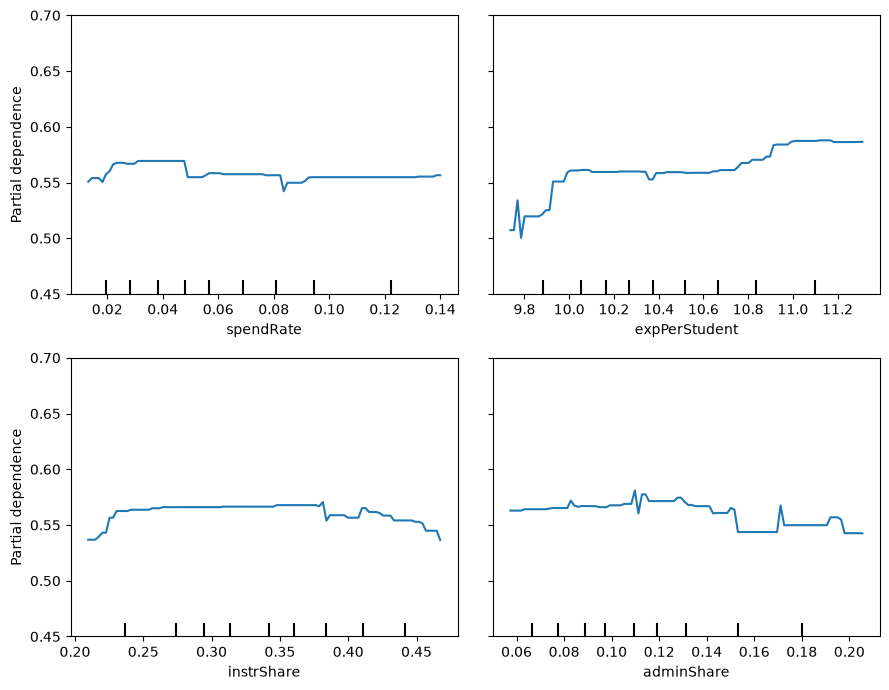

In [113]:
X_trainPd = X_train.fillna(X_train.median(numeric_only=True))
GBModelInitial = pipes["gbm"]
GBModelInitial.fit(X_train, y_train, model__sample_weight = w_train)
figPdpSpending, axes = plt.subplots(2, 2, figsize=(9, 7))
PartialDependenceDisplay.from_estimator(GBModelInitial, X_trainPd, features=["spendRate", "expPerStudent", "instrShare", "adminShare"],
                                        categorical_features=["division", "admRateMissing", "testScoreMissing"],
                                        kind="average", n_cols=2, ax=axes)
for a in figPdpSpending.axes:
    a.set_ylim(0.45, 0.70)
plt.tight_layout(); plt.show()

Athletic, administrative, and instructional spending shares are flat. Expenses per student drifts up a little (~5 points over a 4x range of spending), which ablation says is indistinguishable from zero.

Why does raw division matter so much (47% D-II vs 67% FBS) when the adjusted effect is ~3 points? Because divisions enroll different students.
 
FBS vs FCS is the clean comparison: nearly identical athletic spending shares (7.2% vs 7.7%), 14 point graduation gap, 120 point test score gap. If spending drove graduation these two rows would look alike.

In [114]:
g = features.groupby("division")
divTable = g[["testScore", "upPell", "ugTotal", "admRate", "spendRate", "gradRate"]].median().round(3)
divTable.insert(0, "n", g.size())
divTable

,n,testScore,upPell,ugTotal,admRate,spendRate,gradRate
division,,,,,,,
D-I FBS,108,1198.737,0.26,22673.5,0.770,0.072,0.672
D-I FCS,75,1080.000,0.33,8215.0,0.859,0.077,0.531
D-I no football,46,1114.309,0.33,11962.0,0.814,0.043,0.555
D-II,143,1075.477,0.37,5265.0,0.871,0.057,0.473
D-III,73,1173.455,0.34,4859.0,0.807,0.022,0.584


# Conclusion
 
Athletic spending share has no robust association with graduation rate. It's null unadjusted, flips sign twice under partial controls (confounding), and lands around -0.25 with full composition controls, about 1.2 graduation points per 5 point increase in spending share, borderline significant and sensitive to weighting. The GBM finds no predictive value in any spending measure.
 
Graduation rates are driven by Pell share, test scores, enrollment size, and selectivity. Division differences are almost entirely composition.
 
Under no specification is there evidence that athletic spending is associated with lower graduation rates.

# Outputs

In [ ]:
# Tables
cv_table.to_csv("../Output/Tables/07_cv_model_comparison.csv", index_label="model")

order.rename("rank").rename_axis("feature").to_csv("../Output/Tables/08_rfe_feature_ranking.csv")

deltaTable.round(4).to_csv("../Output/Tables/09_ablation_rmse_delta.csv", index_label="dropped")

pd.DataFrame([{
    "model": "GBM (final)",
    "nFeatures": X_train.drop(columns=dropList).shape[1],
    "nTest": len(y_test),
    "rmse": rmse,
    "r2": r2,
}]).round(4).to_csv("../Output/Tables/10_test_set_metrics.csv", index=False)

divTable.to_csv("../Output/Tables/11_division_composition.csv", index_label="division")

wlsFull.to_csv("../Output/Tables/12_wls_full_model.csv")

# Plots
figRfecv.savefig("../Output/Plots/07_rfecv_curve.png", dpi=300, bbox_inches="tight")
figAblation.savefig("../Output/Plots/08_ablation_importance.png", dpi=300, bbox_inches="tight")
figPred.savefig("../Output/Plots/09_pred_vs_actual.png", dpi=300, bbox_inches="tight")
figPdpFinal.savefig("../Output/Plots/10_pdp_final_model.png", dpi=300, bbox_inches="tight")
figPdpSpending.savefig("../Output/Plots/11_pdp_spending_full_model.png", dpi=300, bbox_inches="tight")
